# Groundwater Productivity Processing

## Purpose

Convert the raw British Geological Survey / MacDonald et al. groundwater productivity xyz ASCII grid into a GeoPackage used by the water-source notebooks.

## Source

The source dataset is the BGS quantitative groundwater productivity map for Africa. It is a 5 km xyz ASCII grid of representative borehole yield classes in liters per second. The BGS page describes the layer as continental/regional-scale information, so downstream analyses should treat it as a regional groundwater-productivity class map rather than field-level well-yield measurements.

Download page: https://www2.bgs.ac.uk/groundwater/international/africanGroundwater/mapsDownload.html

DOI catalogue record: https://doi.org/10.5285/e37d09e7-6388-494b-99c8-10958d6d78c4

## Inputs

| Dataset | Config key | Notes |
|---------|------------|-------|
| Raw BGS productivity xyz ASCII | `Groundwater_Productivity_path` | Usually `xyzASCII_gwprod_v1.txt`; if a zip is present in the same folder, this notebook can extract the first non-readme text-like data file |

## Outputs

| File | Config key | Description |
|------|------------|-------------|
| `Groundwater_Prod.gpkg` | `Groundwater_Prod_gpkg_path` | EPSG:4326 point GeoPackage with `X`, `Y`, `gwprod_code`, `Liters_Second`, `productivity_class`, and `yield_range` |


In [1]:
# --- Import required libraries and utilities ---
import os
import sys
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from Code.utils.utility import load_config, resolve_path

config = load_config()

raw_path = Path(resolve_path(config['Groundwater_Productivity_path']))
output_path = Path(resolve_path(config['Groundwater_Prod_gpkg_path']))

print(f'Raw path:    {raw_path}')
print(f'Output path: {output_path}')

Raw path:    C:\Users\ermil\Documents\Africa_Irrigation\Data\Raw\Groundwater_Productivity-txt\xyzASCII_gwprod_v1.txt
Output path: C:\Users\ermil\Documents\Africa_Irrigation\Data\Processed\Groundwater_Prod.gpkg


In [2]:
# --- Productivity class mapping ---
# The raw BGS file stores categorical productivity codes. Liters_Second is a
# representative value for each range, kept for simple joins and summaries.
productivity_classes = pd.DataFrame(
    [
        ('VL', 0.1, 'Very low', '<0.1 L/s'),
        ('L', 0.3, 'Low', '0.1-0.5 L/s'),
        ('LM', 0.75, 'Low to moderate', '0.5-1 L/s'),
        ('M', 3.0, 'Moderate', '1-5 L/s'),
        ('H', 12.5, 'High', '5-20 L/s'),
        ('VH', 20.0, 'Very high', '>20 L/s'),
    ],
    columns=['gwprod_code', 'Liters_Second', 'productivity_class', 'yield_range'],
)

display(productivity_classes)

,gwprod_code,Liters_Second,productivity_class,yield_range
0,VL,0.10,Very low,<0.1 L/s
1,L,0.30,Low,0.1-0.5 L/s
2,LM,0.75,Low to moderate,0.5-1 L/s
3,M,3.00,Moderate,1-5 L/s
4,H,12.50,High,5-20 L/s
5,VH,20.00,Very high,>20 L/s


## Load Raw XYZ Data

If the configured text file is missing but a zip exists in the same folder, extract the first non-readme text-like data file. Otherwise, place the BGS xyz ASCII download at `Groundwater_Productivity_path`.

In [3]:
# --- Locate or extract raw xyz text file ---
if not raw_path.exists():
    zip_candidates = sorted(raw_path.parent.glob('*.zip')) if raw_path.parent.exists() else []
    extracted = False
    for zip_path in zip_candidates:
        with zipfile.ZipFile(zip_path) as zf:
            members = [
                name for name in zf.namelist()
                if name.lower().endswith(('.txt', '.xyz', '.asc', '.csv'))
                and 'readme' not in name.lower()
            ]
            if not members:
                continue
            raw_path.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(members[0]) as src, raw_path.open('wb') as dst:
                dst.write(src.read())
            print(f'Extracted {members[0]} from {zip_path} to {raw_path}')
            extracted = True
            break
    if not extracted:
        raise FileNotFoundError(
            f'Raw groundwater file not found: {raw_path}\n'
            'Download the BGS groundwater productivity xyz ASCII file and place it at this path, '
            'or update Groundwater_Productivity_path in config.yaml.'
        )

print(f'Using raw file: {raw_path}')

Using raw file: C:\Users\ermil\Documents\Africa_Irrigation\Data\Raw\Groundwater_Productivity-txt\xyzASCII_gwprod_v1.txt


In [4]:
# --- Parse x/y/productivity rows ---
records = []
skipped = 0
class_lookup = productivity_classes.set_index('gwprod_code').to_dict('index')
numeric_lookup = productivity_classes.set_index('Liters_Second').to_dict('index')

with raw_path.open('r', encoding='utf-8', errors='replace') as f:
    for line in f:
        stripped = line.strip()
        if not stripped or stripped.startswith(('#', '//')):
            continue
        parts = stripped.replace(',', ' ').split()
        if len(parts) < 3:
            skipped += 1
            continue
        try:
            x, y = float(parts[0]), float(parts[1])
        except ValueError:
            skipped += 1
            continue

        raw_value = parts[2].strip()
        code = raw_value.upper()
        if code in class_lookup:
            info = class_lookup[code]
            records.append((x, y, code, info['Liters_Second'], info['productivity_class'], info['yield_range']))
            continue

        try:
            liters_second = float(raw_value)
        except ValueError:
            skipped += 1
            continue

        info = numeric_lookup.get(liters_second, {})
        records.append((
            x,
            y,
            info.get('gwprod_code'),
            liters_second,
            info.get('productivity_class'),
            info.get('yield_range'),
        ))

if not records:
    raise ValueError(f'No xyz rows could be parsed from {raw_path}')

gw_df = pd.DataFrame(
    records,
    columns=['X', 'Y', 'gwprod_code', 'Liters_Second', 'productivity_class', 'yield_range'],
)

print(f'Parsed {len(gw_df):,} groundwater productivity rows')
print(f'Skipped {skipped:,} non-data/header rows')
display(gw_df.head())

unknown_values = sorted(gw_df.loc[gw_df['productivity_class'].isna(), 'Liters_Second'].dropna().unique())
if unknown_values:
    print('Warning: numeric values outside known productivity classes:', unknown_values)

Parsed 1,008,704 groundwater productivity rows
Skipped 10,562 non-data/header rows


,X,Y,gwprod_code,Liters_Second,productivity_class,yield_range
0,9.41405,37.251192,M,3.0,Moderate,1-5 L/s
1,9.46405,37.251192,M,3.0,Moderate,1-5 L/s
2,9.51405,37.251192,M,3.0,Moderate,1-5 L/s
3,9.56405,37.251192,M,3.0,Moderate,1-5 L/s
4,9.61405,37.251192,H,12.5,High,5-20 L/s


## Write GeoPackage

In [5]:
# --- Convert to EPSG:4326 point GeoPackage ---
gw_gdf = gpd.GeoDataFrame(
    gw_df,
    geometry=gpd.points_from_xy(gw_df['X'], gw_df['Y']),
    crs='EPSG:4326',
)

output_path.parent.mkdir(parents=True, exist_ok=True)
if output_path.exists():
    output_path.unlink()
gw_gdf.to_file(output_path, driver='GPKG', layer='groundwater_productivity')

print(f'Wrote {len(gw_gdf):,} points to {output_path}')
print('\nProductivity value counts:')
print(gw_gdf['Liters_Second'].value_counts(dropna=False).sort_index())

Wrote 1,008,704 points to C:\Users\ermil\Documents\Africa_Irrigation\Data\Processed\Groundwater_Prod.gpkg

Productivity value counts:
Liters_Second
0.10      29683
0.30     176127
0.75     184202
3.00     270050
12.50    262623
20.00     86019
Name: count, dtype: int64


Reloaded 1,008,704 records
CRS: EPSG:4326
Bounds: [-17.38594971 -34.79880822  51.21405029  37.25119178]


,X,Y,gwprod_code,Liters_Second,productivity_class,yield_range
0,9.41405,37.251192,M,3.0,Moderate,1-5 L/s
1,9.46405,37.251192,M,3.0,Moderate,1-5 L/s
2,9.51405,37.251192,M,3.0,Moderate,1-5 L/s
3,9.56405,37.251192,M,3.0,Moderate,1-5 L/s
4,9.61405,37.251192,H,12.5,High,5-20 L/s


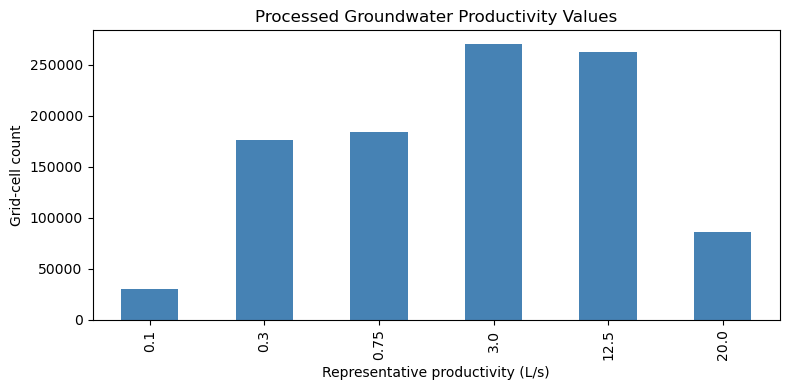

In [6]:
# --- Validate written output and quick-look plot ---
gw_check = gpd.read_file(output_path)
print(f'Reloaded {len(gw_check):,} records')
print(f'CRS: {gw_check.crs}')
print(f'Bounds: {gw_check.total_bounds}')
display(gw_check[['X', 'Y', 'gwprod_code', 'Liters_Second', 'productivity_class', 'yield_range']].head())

fig, ax = plt.subplots(figsize=(8, 4))
gw_check['Liters_Second'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Representative productivity (L/s)')
ax.set_ylabel('Grid-cell count')
ax.set_title('Processed Groundwater Productivity Values')
plt.tight_layout()
plt.show()